In [1]:
from jax import config
config.update("jax_platform_name", "cpu")
from functools import partial

import numpy as np
from jax import grad, jit, lax, nn
from jax import numpy as jnp
from jax import random, value_and_grad, vmap
from jax.example_libraries import optimizers
from matplotlib import pyplot as plt
from tqdm import tqdm
import pandas as pd

from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import (
    Domain,
    Medium,
    Sensors,
    Sources,
    TimeAxis,
    circ_mask,
    points_on_circle,
)
from jwave.signal_processing import apply_ramp, gaussian_window, smooth

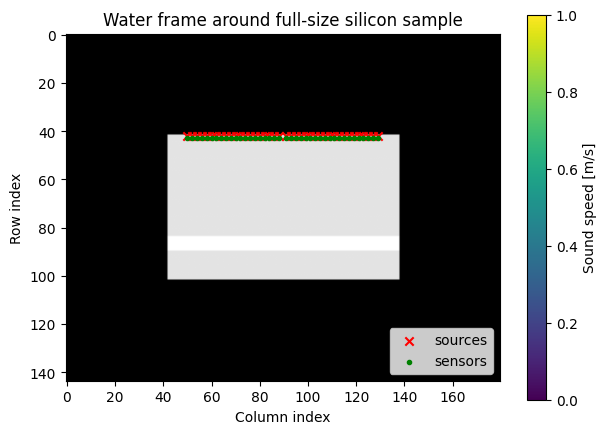

dt = 1.078e-10 s
Total simulation time = 0.323 µs
sample_top: 42
source_row: 42
sensor_row: 43
speed at source row: 8433.0
speed at sensor row: 8433.0
water_speed: 1480.0
si_speed: 8433.0


In [32]:
# Settings
scale_factor = 20

# Silicon sample size
# sample_N = (60, 96), dx = 5 µm
# Physical size = 300 µm × 480 µm
sample_N = (60, 96)
dx = (5e-6, 5e-6)

# Water frame thickness around all faces of the sample
# About 1/3 of the sample height: 128 / 3 ≈ 42 cells
#water_cells = sample_N[0] // 3

water_cells = 42
# Full simulation domain = water frame + original silicon sample
N = (
    sample_N[0] + 2 * water_cells,
    sample_N[1] + 2 * water_cells,
)

cfl = 0.2
num_sources = 40
source_freq = 1e6 * 1 * scale_factor
# source_mag = 1.3e-5
source_mag = 800.0

random_seed = random.PRNGKey(42)

# Define domain
domain = Domain(N, dx)


# ============================================================
# Define medium: water frame around full-size silicon sample
# ============================================================

water_speed = 1480.0   # m/s, approximate speed of sound in water
si_speed = 8433.0      # m/s, silicon-like speed from your original code

# Silicon sample location inside the larger water domain
sample_top = water_cells
sample_left = water_cells
sample_bottom = sample_top + sample_N[0]
sample_right = sample_left + sample_N[1]

# Start with water everywhere
sound_speed = water_speed * jnp.ones(N)

# Create a silicon sample mask
# 0 = water
# 1 = silicon sample
sample_mask = jnp.zeros(N)
sample_mask = sample_mask.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(1.0)

# Put silicon speed inside the sample region
sound_speed = sound_speed * (1.0 - sample_mask) + si_speed * sample_mask


# ============================================================
# Circular inclusions inside the silicon sample
# ============================================================
# Original circle centers were in the old sample coordinates:
# circle_1: (50, 38)
# circle_2: (82, 48)
# circle_3: (65, 49)
#
# Now the sample is shifted by:
# row shift = sample_top
# col shift = sample_left

# circle_1 = circ_mask(N, 8,  (sample_top + 23, sample_left + 38)) * sample_mask
# circle_2 = circ_mask(N, 10, (sample_top + 38, sample_left + 48)) * sample_mask
# circle_3 = circ_mask(N, 20, (sample_top + 30, sample_left + 49)) * sample_mask

# sound_speed = sound_speed + si_speed * (
#     0.05 * circle_1 + 0.02 * circle_2 + 0.03 * circle_3
# )


# ============================================================
# Tectonic-like horizontal layer inside the silicon sample
# ============================================================
# Remove circular inclusions and create one band inside the Si sample.
#
# Band thickness = 10% of the silicon sample height
# Band position  = around 3/4 depth of the silicon sample

layer_thickness = int(0.10 * sample_N[0])   # 10% of Si sample height
layer_center = sample_top + int(0.75 * sample_N[0])

layer_top = layer_center - layer_thickness // 2
layer_bottom = layer_top + layer_thickness

# Safety: keep the layer inside the silicon sample
layer_top = max(layer_top, sample_top)
layer_bottom = min(layer_bottom, sample_bottom)

tectonic_layer = jnp.zeros(N)
tectonic_layer = tectonic_layer.at[
    layer_top:layer_bottom,
    sample_left:sample_right
].set(1.0)

tectonic_layer = tectonic_layer * sample_mask

# Example: make the tectonic layer 10% faster than silicon
layer_contrast = 0.10

sound_speed = sound_speed + si_speed * layer_contrast * tectonic_layer


# Convert the sound-speed map into a j-wave FourierSeries field
sound_speed = FourierSeries(jnp.expand_dims(sound_speed, -1), domain)

medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8.0)


# ============================================================
# Time axis
# ============================================================

time_axis = TimeAxis.from_medium(medium, cfl=cfl)

# Force a long time window, as in your reference figure
n_steps = 3000
time_axis = TimeAxis(dt=time_axis.dt, t_end=n_steps * time_axis.dt)
t = time_axis.to_array()


# ============================================================
# Source signal
# ============================================================

s1 = source_mag * jnp.sin(2 * jnp.pi * source_freq * t)

# Pulse position to avoid shift
center_index = 200
center_time = center_index * time_axis.dt

# Gaussian pulse width
#sigma_time = 24e-9
sigma_time = 12e-9

signal = gaussian_window(
    apply_ramp(s1, time_axis.dt, source_freq),
    t,
    center_time,
    sigma_time
)


# ============================================================
# Sources and sensors directly at the sample surface
# ============================================================

num_sensors = num_sources  # 80 sensors because num_sources = 80

# The silicon sample starts at row sample_top.
# sample_top - 1 is the last water row before the silicon.
# This places the sources and sensors directly above the sample surface,
# but still inside the surrounding water.
source_row = sample_top 
sensor_row = sample_top + 1

# Horizontally, place sources/sensors across the silicon sample width.
# We avoid the exact sample edges by using an 8-cell margin inside the sample width.
cols = jnp.linspace(
    sample_left + 8,
    sample_right - 9,
    num_sources
).round().astype(int)

source_positions = (
    jnp.full((num_sources,), source_row, dtype=int),
    cols,
)

sensors_positions = (
    jnp.full((num_sensors,), sensor_row, dtype=int),
    cols,
)

sensors = Sensors(positions=sensors_positions)


# ============================================================
# Optional: visualize the new setup
# ============================================================

plt.figure(figsize=(7, 5))
plt.imshow(medium.sound_speed.on_grid[..., 0], cmap="gray")
plt.scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)
plt.scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)
plt.colorbar(label="Sound speed [m/s]")
plt.legend(loc="lower right")
plt.title("Water frame around full-size silicon sample")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()


total_time_us = n_steps * time_axis.dt * 1e6
print(f"dt = {time_axis.dt:.3e} s")
print(f"Total simulation time = {total_time_us:.3f} µs")


# ============================================================
# Optional: old circular source/sensor setup
# ============================================================

# x, y = points_on_circle(num_sources, 40, (64, 48))
# source_positions = (jnp.array(x), jnp.array(y))

# sensors_positions = (x, y)
# sensors = Sensors(positions=sensors_positions)

speed_grid = medium.sound_speed.on_grid[..., 0]

print("sample_top:", sample_top)

print("source_row:", source_row)

print("sensor_row:", sensor_row)

print("speed at source row:", float(speed_grid[int(source_row), int(cols[0])]))

print("speed at sensor row:", float(speed_grid[int(sensor_row), int(cols[0])]))

print("water_speed:", water_speed)

print("si_speed:", si_speed)

Text(0.5, 1.0, 'Source signals')

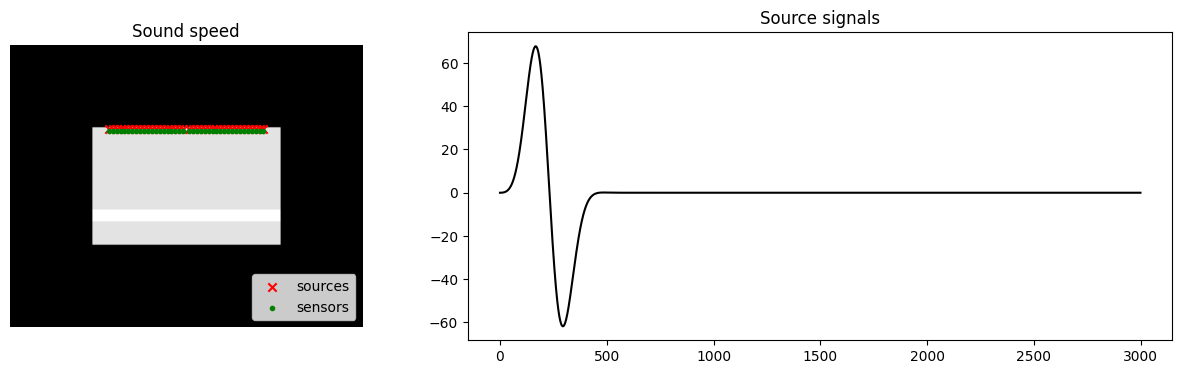

In [33]:
# Show simulation setup
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 2]})

ax[0].imshow(medium.sound_speed.on_grid, cmap="gray")
ax[0].scatter(
    source_positions[1], source_positions[0], c="r", marker="x", label="sources"
)
ax[0].scatter(
    sensors_positions[1], sensors_positions[0], c="g", marker=".", label="sensors"
)
ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source 1", c="k")
ax[1].set_title("Source signals")
#ax[1].get_yaxis().set_visible(False)



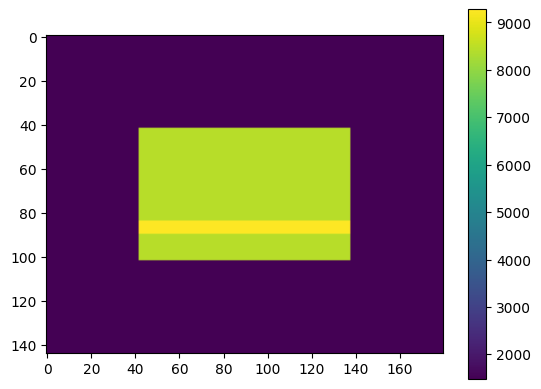

In [34]:
plt.imshow(medium.sound_speed.on_grid)
plt.colorbar()

In [35]:
src_signal = jnp.stack([signal])

# We can compile the entire function! All the constructors
# that don't depend on the inputs will be statically compiled
# and run only once.
@jit
def single_source_simulation(sound_speed, source_num):
    # Setting source
    x = lax.dynamic_slice(source_positions[0], (source_num,), (1,))
    y = lax.dynamic_slice(source_positions[1], (source_num,), (1,))
    sources = Sources((x, y), src_signal, dt=time_axis.dt, domain=domain)

    # Updating medium with the input speed of sound map
    medium = Medium(domain=domain, sound_speed=sound_speed, pml_size=8)

    # Run simulations
    # rf_signals = simulate_wave_propagation(
    #     medium, time_axis, sources=sources, sensors=sensors, checkpoint=True
    # )
    rf_signals = simulate_wave_propagation(
        medium, time_axis, sources=sources, sensors=sensors,
    )
    return rf_signals[..., 0]

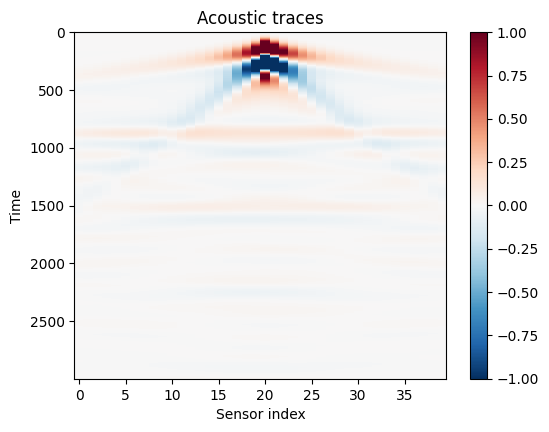

In [36]:

p = single_source_simulation(medium.sound_speed, 20)

# Visualize the acoustic traces
plt.figure(figsize=(6, 4.5))
maxval = jnp.amax(jnp.abs(p))
plt.imshow(
    p, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest", aspect="auto"
    
)
plt.colorbar()
plt.title("Acoustic traces")
plt.xlabel("Sensor index")
plt.ylabel("Time")
plt.show()

In [37]:
print("sample_top:", sample_top)
print("sample_bottom:", sample_bottom)
print("source_row:", source_row)
print("sensor_row:", sensor_row)

if sensor_row < sample_top:
    print("Sensors are in water above the Si sample.")
elif sensor_row >= sample_bottom:
    print("Sensors are below the Si sample.")
else:
    print("Sensors are inside the Si sample.")

speed_grid = medium.sound_speed.on_grid[..., 0]

print("Speed at sensor row, first sensor:",
      speed_grid[int(sensor_row), int(cols[0])])

print("Expected water speed:", water_speed)
print("Expected Si speed:", si_speed)

sample_top: 42
sample_bottom: 102
source_row: 42
sensor_row: 43
Sensors are inside the Si sample.
Speed at sensor row, first sensor: 8433.0
Expected water speed: 1480.0
Expected Si speed: 8433.0


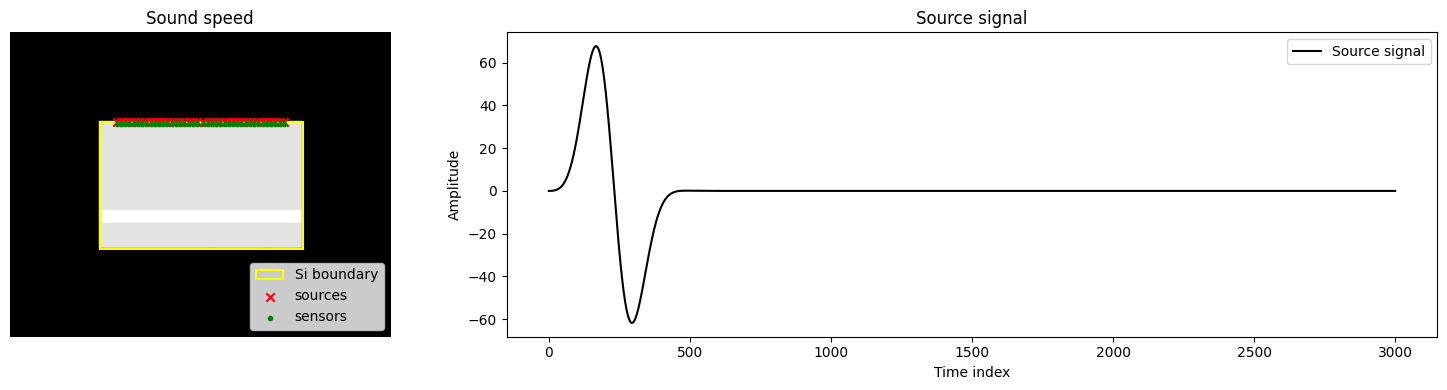

In [38]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(15, 4),
    gridspec_kw={"width_ratios": [1, 2]}
)

speed_grid = medium.sound_speed.on_grid[..., 0]

ax[0].imshow(speed_grid, cmap="gray")

# Draw silicon sample boundary
rect = plt.Rectangle(
    (sample_left, sample_top),
    sample_right - sample_left,
    sample_bottom - sample_top,
    fill=False,
    edgecolor="yellow",
    linewidth=1.5,
    label="Si boundary"
)
ax[0].add_patch(rect)

ax[0].scatter(
    source_positions[1],
    source_positions[0],
    c="r",
    marker="x",
    label="sources"
)

ax[0].scatter(
    sensors_positions[1],
    sensors_positions[0],
    c="g",
    marker=".",
    label="sensors"
)

ax[0].legend(loc="lower right")
ax[0].set_title("Sound speed")
ax[0].axis("off")

ax[1].plot(signal, label="Source signal", c="k")
ax[1].set_title("Source signal")
ax[1].set_xlabel("Time index")
ax[1].set_ylabel("Amplitude")
ax[1].legend()

plt.tight_layout()
plt.show()

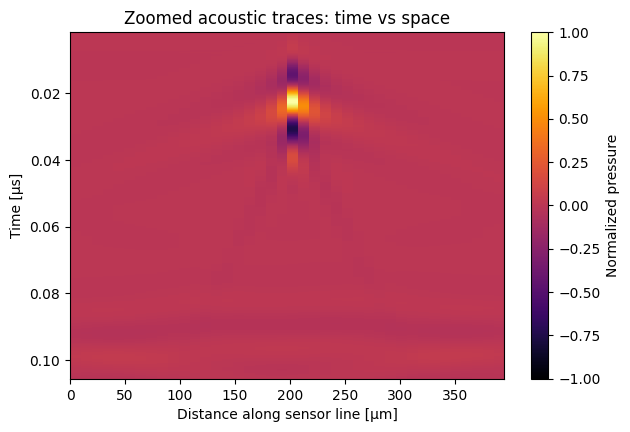

In [9]:
# ============================================================
# Prepare p
# ============================================================
p_np = np.array(p)
# Make sure shape is time × sensors
if p_np.shape[0] == num_sensors:
    p_np = p_np.T
n_time, n_sensors = p_np.shape
# Normalize
p_norm = p_np / np.nanmax(np.abs(p_np))
# Axes
time_us = np.arange(n_time) * float(time_axis.dt) * 1e6
sensor_cols = np.array(cols)
sensor_x_um = sensor_cols * dx[1] * 1e6
sensor_x_um = sensor_x_um - sensor_x_um[0]

# ============================================================
# Auto zoom to useful signal
# ============================================================
# Energy per time step
energy_t = np.max(np.abs(p_norm), axis=1)
# Find where signal is visible
zoom_threshold = 0.03
visible_idx = np.where(energy_t > zoom_threshold)[0]
if len(visible_idx) > 0:
    t0_idx = max(0, visible_idx[0] - 20)
    t1_idx = min(n_time - 1, visible_idx[-1] + 40)
else:
    t0_idx = 0
    t1_idx = n_time - 1
time_zoom_us = time_us[t0_idx:t1_idx + 1]
p_zoom = p_norm[t0_idx:t1_idx + 1, :]

# ============================================================
# Plot zoomed time-space diagram
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.imshow(
    p_zoom,
    cmap="inferno",
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="auto",
    extent=[
        sensor_x_um[0],
        sensor_x_um[-1],
        time_zoom_us[-1],
        time_zoom_us[0],
    ],
)
plt.colorbar(label="Normalized pressure")
plt.title("Zoomed acoustic traces: time vs space")
plt.xlabel("Distance along sensor line [µm]")
plt.ylabel("Time [µs]")
plt.show()

In [11]:
# ============================================================
# INDEPENDENT ARRIVAL PICKING + FAST/SLOW ANALYSIS CSV
# No previous arrival-analysis blocks required
# Uses: p, time_axis, cols, dx, num_sensors
# ============================================================

import os
import numpy as np
import pandas as pd
import jax.numpy as jnp
from jwave.signal_processing import analytic_signal

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

source_index = 40

# Silicon reference speed
reference_speed_m_s = 8433.0

# Arrival picker threshold: 40% of each sensor peak
arrival_fraction = 0.40

# Start searching slightly before the expected Si arrival
safety_margin_us = 0.003

# Classification tolerance
timing_tolerance_ns = 1.0

# Maximum expected speed increase from defects
# circle_1 = +5%, circle_2 = +2%, circle_3 = +3%
# Use 0.10 as conservative maximum if they overlap
max_speed_increase_fraction = 0.10

# Output folder
output_dir = "arrival_analysis_outputs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------
# Convert pressure to numpy and make sure shape is [time, sensors]
# ------------------------------------------------------------

p_np = np.array(p)

if p_np.shape[0] == num_sensors:
    p_np = p_np.T

n_time, n_sensors = p_np.shape

print("p_np shape [time, sensors]:", p_np.shape)

# ------------------------------------------------------------
# Time axis
# ------------------------------------------------------------

time_us = np.arange(n_time) * float(time_axis.dt) * 1e6
time_ns = time_us * 1000.0

print("Total simulation time steps:", n_time)
print("Maximum possible time index:", n_time - 1)
print("dt [ns]:", float(time_axis.dt) * 1e9)
print("Final simulation time [ns]:", time_ns[-1])

# ------------------------------------------------------------
# Sensor positions and distance from source
# ------------------------------------------------------------

sensor_cols = np.array(cols)
sensor_x_um = sensor_cols * dx[1] * 1e6
sensor_x_um = sensor_x_um - sensor_x_um[0]

source_x_um = sensor_x_um[source_index]
distance_from_source_um = np.abs(sensor_x_um - source_x_um)

print("Source index:", source_index)
print("Source x position [um]:", source_x_um)

# ------------------------------------------------------------
# Hilbert envelope
# ------------------------------------------------------------

def hilbert_transf(signal):
    return np.abs(np.array(analytic_signal(jnp.array(signal))))

p_env = hilbert_transf(p_np)

global_max = np.nanmax(p_env)

# ------------------------------------------------------------
# Initialize arrays
# ------------------------------------------------------------

arrival_idx_full = np.full(n_sensors, np.nan)
arrival_time_full_us = np.full(n_sensors, np.nan)

expected_arrival_us_array = np.full(n_sensors, np.nan)
search_start_us_array = np.full(n_sensors, np.nan)
search_start_idx_array = np.full(n_sensors, np.nan)

arrival_residual_us = np.full(n_sensors, np.nan)
apparent_speed_m_s = np.full(n_sensors, np.nan)
speed_ratio_vs_reference = np.full(n_sensors, np.nan)

sensor_peak = np.full(n_sensors, np.nan)
sensor_peak_fraction_global = np.full(n_sensors, np.nan)

# ------------------------------------------------------------
# Arrival picking
# ------------------------------------------------------------

for s in range(n_sensors):

    trace_env = p_env[:, s]

    local_max = np.nanmax(trace_env)
    sensor_peak[s] = local_max
    sensor_peak_fraction_global[s] = local_max / global_max

    if local_max <= 0 or np.isnan(local_max):
        continue

    # Distance from source in meters
    distance_m = distance_from_source_um[s] * 1e-6

    # Expected arrival time in homogeneous Si
    expected_arrival_us = distance_m / reference_speed_m_s * 1e6
    expected_arrival_us_array[s] = expected_arrival_us

    # Start search slightly before expected arrival
    search_start_us = max(0.0, expected_arrival_us - safety_margin_us)
    search_start_us_array[s] = search_start_us

    search_start_idx = int(np.searchsorted(time_us, search_start_us))
    search_start_idx = min(search_start_idx, n_time - 1)
    search_start_idx_array[s] = search_start_idx

    # Local threshold
    local_threshold = arrival_fraction * local_max

    hits = np.where(trace_env[search_start_idx:] >= local_threshold)[0]

    if len(hits) > 0:
        arrival_idx_full[s] = search_start_idx + hits[0]
        arrival_time_full_us[s] = time_us[int(arrival_idx_full[s])]

    # Residual and apparent speed
    if not np.isnan(arrival_time_full_us[s]):

        arrival_residual_us[s] = arrival_time_full_us[s] - expected_arrival_us

        if distance_m > 0:
            apparent_speed_m_s[s] = distance_m / (arrival_time_full_us[s] * 1e-6)
            speed_ratio_vs_reference[s] = apparent_speed_m_s[s] / reference_speed_m_s

# ------------------------------------------------------------
# Convert to nanoseconds
# ------------------------------------------------------------

arrival_time_ns = arrival_time_full_us * 1000.0
expected_arrival_time_ns = expected_arrival_us_array * 1000.0
arrival_residual_ns = arrival_residual_us * 1000.0
arrival_advance_ns = expected_arrival_time_ns - arrival_time_ns

search_start_time_ns = search_start_us_array * 1000.0

# ------------------------------------------------------------
# Percent changes
# ------------------------------------------------------------

# arrival_residual_percent = (
#     100.0 * arrival_residual_ns / expected_arrival_time_ns
# )

# arrival_advance_percent = (
#     100.0 * arrival_advance_ns / expected_arrival_time_ns
# )

# # Avoid division by zero at source sensor
# arrival_residual_percent[expected_arrival_time_ns == 0] = np.nan
# arrival_advance_percent[expected_arrival_time_ns == 0] = np.nan


# ------------------------------------------------------------
# Percent changes
# Avoid division by zero at the source sensor
# ------------------------------------------------------------

arrival_residual_percent = np.full(n_sensors, np.nan)
arrival_advance_percent = np.full(n_sensors, np.nan)

valid_expected = expected_arrival_time_ns > 0

arrival_residual_percent[valid_expected] = (
    100.0
    * arrival_residual_ns[valid_expected]
    / expected_arrival_time_ns[valid_expected]
)

arrival_advance_percent[valid_expected] = (
    100.0
    * arrival_advance_ns[valid_expected]
    / expected_arrival_time_ns[valid_expected]
)


# ------------------------------------------------------------
# Behavior classification
# Positive advance = faster than expected
# ------------------------------------------------------------

arrival_behavior = np.full(n_sensors, "no_detection", dtype=object)

for s in range(n_sensors):

    if np.isnan(arrival_time_ns[s]):
        arrival_behavior[s] = "no_detection"

    elif arrival_advance_ns[s] > timing_tolerance_ns:
        arrival_behavior[s] = "faster_than_expected"

    elif arrival_advance_ns[s] < -timing_tolerance_ns:
        arrival_behavior[s] = "slower_than_expected"

    else:
        arrival_behavior[s] = "as_expected"

# ------------------------------------------------------------
# Physical diagnostic without t0_source correction
# ------------------------------------------------------------

max_possible_speed_m_s = reference_speed_m_s * (1.0 + max_speed_increase_fraction)

distance_m_all = distance_from_source_um * 1e-6

travel_time_reference_ns = distance_m_all / reference_speed_m_s * 1e9
travel_time_fastest_ns = distance_m_all / max_possible_speed_m_s * 1e9

max_possible_advance_ns = travel_time_reference_ns - travel_time_fastest_ns

advance_excess_ns = arrival_advance_ns - max_possible_advance_ns

advance_is_physically_suspicious = advance_excess_ns > 1.0

# ------------------------------------------------------------
# Create final DataFrame
# ------------------------------------------------------------

arrival_table_direct_first_all_sensors = pd.DataFrame({
    "arrival_type": "direct_first_arrival",
    "sensor_index": np.arange(n_sensors),
    "x_position_um": sensor_x_um,
    "distance_from_source_um": distance_from_source_um,

    # Detected arrival
    "arrival_time_us": arrival_time_full_us,
    "arrival_time_ns": arrival_time_ns,
    "arrival_sample_index": arrival_idx_full,

    # Expected arrival in homogeneous Si
    "expected_arrival_time_us": expected_arrival_us_array,
    "expected_arrival_time_ns": expected_arrival_time_ns,

    # Residual: detected - expected
    # Negative residual = faster than expected
    "arrival_residual_us": arrival_residual_us,
    "arrival_residual_ns": arrival_residual_ns,
    "arrival_residual_percent": arrival_residual_percent,

    # Advance: expected - detected
    # Positive advance = faster than expected
    "arrival_advance_ns": arrival_advance_ns,
    "arrival_advance_percent": arrival_advance_percent,

    # Search-window debug
    "search_start_time_us": search_start_us_array,
    "search_start_time_ns": search_start_time_ns,
    "search_start_index": search_start_idx_array,

    # Speed interpretation
    "reference_speed_m_s": reference_speed_m_s,
    "apparent_speed_m_s": apparent_speed_m_s,
    "speed_ratio_vs_reference": speed_ratio_vs_reference,
    "arrival_behavior": arrival_behavior,

    # Physical diagnostic
    "max_speed_increase_fraction": max_speed_increase_fraction,
    "max_possible_speed_m_s": max_possible_speed_m_s,
    "max_possible_advance_ns": max_possible_advance_ns,
    "advance_excess_ns": advance_excess_ns,
    "advance_is_physically_suspicious": advance_is_physically_suspicious,

    # Picker and signal quality
    "threshold_fraction_of_sensor_peak": arrival_fraction,
    "timing_tolerance_ns": timing_tolerance_ns,
    "sensor_peak_envelope": sensor_peak,
    "sensor_peak_normalized_to_global_max": sensor_peak_fraction_global,
})

# ------------------------------------------------------------
# Save full CSV
# ------------------------------------------------------------

full_csv_path = os.path.join(
    output_dir,
    "arrival_table_direct_first_all_sensors_final_no_t0_correction.csv"
)

arrival_table_direct_first_all_sensors.to_csv(full_csv_path, index=False)

# ------------------------------------------------------------
# Save sorted table: strongest advances first
# ------------------------------------------------------------

advance_sorted_table = arrival_table_direct_first_all_sensors.sort_values(
    "arrival_advance_ns",
    ascending=False
)[[
    "sensor_index",
    "x_position_um",
    "distance_from_source_um",
    "arrival_time_ns",
    "expected_arrival_time_ns",
    "arrival_advance_ns",
    "arrival_advance_percent",
    "max_possible_advance_ns",
    "advance_excess_ns",
    "advance_is_physically_suspicious",
    "speed_ratio_vs_reference",
    "arrival_behavior"
]]

sorted_csv_path = os.path.join(
    output_dir,
    "arrival_advance_sorted_no_t0_correction.csv"
)

advance_sorted_table.to_csv(sorted_csv_path, index=False)

# ------------------------------------------------------------
# Display and summary
# ------------------------------------------------------------

display(arrival_table_direct_first_all_sensors)
display(advance_sorted_table)

print("Saved full CSV:", full_csv_path)
print("Saved sorted CSV:", sorted_csv_path)
print("Total sensors:", n_sensors)
print("Valid arrivals:", np.sum(~np.isnan(arrival_time_ns)))
print("Missing arrivals:", np.sum(np.isnan(arrival_time_ns)))
print("Faster than expected:", np.sum(arrival_behavior == "faster_than_expected"))
print("As expected:", np.sum(arrival_behavior == "as_expected"))
print("Slower than expected:", np.sum(arrival_behavior == "slower_than_expected"))
print("Physically suspicious:", np.sum(advance_is_physically_suspicious))

p_np shape [time, sensors]: (3000, 80)
Total simulation time steps: 3000
Maximum possible time index: 2999
dt [ns]: 0.1078016009792293
Final simulation time [ns]: 323.2970013367087
Source index: 40
Source x position [um]: 200.00000000000006


,arrival_type,sensor_index,x_position_um,distance_from_source_um,arrival_time_us,arrival_time_ns,arrival_sample_index,expected_arrival_time_us,expected_arrival_time_ns,arrival_residual_us,...,arrival_behavior,max_speed_increase_fraction,max_possible_speed_m_s,max_possible_advance_ns,advance_excess_ns,advance_is_physically_suspicious,threshold_fraction_of_sensor_peak,timing_tolerance_ns,sensor_peak_envelope,sensor_peak_normalized_to_global_max
0,direct_first_arrival,0,0.0,200.0,0.020806,20.805709,193.0,0.023716,23.716352,-0.002911,...,faster_than_expected,0.1,9276.3,2.156032,0.754611,False,0.4,1.0,1.242538,0.059208
1,direct_first_arrival,1,5.0,195.0,0.020590,20.590106,191.0,0.023123,23.123444,-0.002533,...,faster_than_expected,0.1,9276.3,2.102131,0.431207,False,0.4,1.0,1.252568,0.059686
2,direct_first_arrival,2,10.0,190.0,0.020698,20.697907,192.0,0.022531,22.530535,-0.001833,...,faster_than_expected,0.1,9276.3,2.048230,-0.215603,False,0.4,1.0,1.244385,0.059296
3,direct_first_arrival,3,15.0,185.0,0.020590,20.590106,191.0,0.021938,21.937626,-0.001348,...,faster_than_expected,0.1,9276.3,1.994330,-0.646809,False,0.4,1.0,1.257811,0.059936
4,direct_first_arrival,4,20.0,180.0,0.020698,20.697907,192.0,0.021345,21.344717,-0.000647,...,as_expected,0.1,9276.3,1.940429,-1.293619,False,0.4,1.0,1.252529,0.059684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,direct_first_arrival,75,375.0,175.0,0.020590,20.590106,191.0,0.020752,20.751808,-0.000162,...,as_expected,0.1,9276.3,1.886528,-1.724825,False,0.4,1.0,1.269231,0.060480
76,direct_first_arrival,76,380.0,180.0,0.020698,20.697907,192.0,0.021345,21.344717,-0.000647,...,as_expected,0.1,9276.3,1.940429,-1.293619,False,0.4,1.0,1.252523,0.059684
77,direct_first_arrival,77,385.0,185.0,0.020590,20.590106,191.0,0.021938,21.937626,-0.001348,...,faster_than_expected,0.1,9276.3,1.994330,-0.646809,False,0.4,1.0,1.257807,0.059936
78,direct_first_arrival,78,390.0,190.0,0.020698,20.697907,192.0,0.022531,22.530535,-0.001833,...,faster_than_expected,0.1,9276.3,2.048230,-0.215603,False,0.4,1.0,1.244381,0.059296


,sensor_index,x_position_um,distance_from_source_um,arrival_time_ns,expected_arrival_time_ns,arrival_advance_ns,arrival_advance_percent,max_possible_advance_ns,advance_excess_ns,advance_is_physically_suspicious,speed_ratio_vs_reference,arrival_behavior
73,73,365.0,165.0,16.601447,19.565991,2.964544,15.151516,1.778726,1.185818,True,1.178571,faster_than_expected
7,7,35.0,165.0,16.601447,19.565991,2.964544,15.151516,1.778726,1.185818,True,1.178571,faster_than_expected
9,9,45.0,155.0,15.415629,18.380173,2.964544,16.129033,1.670925,1.293619,True,1.192308,faster_than_expected
71,71,355.0,155.0,15.415629,18.380173,2.964544,16.129033,1.670925,1.293619,True,1.192308,faster_than_expected
11,11,55.0,145.0,14.229811,17.194356,2.964544,17.241380,1.563123,1.401421,True,1.208333,faster_than_expected
...,...,...,...,...,...,...,...,...,...,...,...,...
38,38,190.0,10.0,13.367399,1.185818,-12.181581,-1027.272717,0.107802,-12.289383,False,0.088710,slower_than_expected
42,42,210.0,10.0,13.367399,1.185818,-12.181581,-1027.272717,0.107802,-12.289383,False,0.088710,slower_than_expected
39,39,195.0,5.0,13.151795,0.592909,-12.558887,-2118.181799,0.053901,-12.612787,False,0.045082,slower_than_expected
41,41,205.0,5.0,13.151795,0.592909,-12.558887,-2118.181799,0.053901,-12.612787,False,0.045082,slower_than_expected


Saved full CSV: arrival_analysis_outputs/arrival_table_direct_first_all_sensors_final_no_t0_correction.csv
Saved sorted CSV: arrival_analysis_outputs/arrival_advance_sorted_no_t0_correction.csv
Total sensors: 80
Valid arrivals: 80
Missing arrivals: 0
Faster than expected: 27
As expected: 10
Slower than expected: 43
Physically suspicious: 16


In [34]:
%%timeit
single_source_simulation(medium.sound_speed, 1).block_until_ready()

3.45 s ± 10.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [39]:
batch_simulations = vmap(single_source_simulation, in_axes=(None, 0))
p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))
print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

Size of data [Source idx, Time, Sensor idx]: (40, 3000, 40)


In [36]:
%%timeit
batch_simulations(medium.sound_speed, jnp.arange(num_sources)).block_until_ready()

4min 47s ± 1.84 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


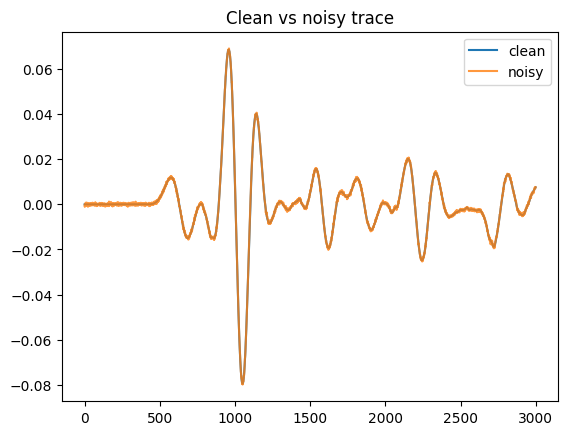

In [40]:
# ============================================================
# ADD PER-TRACE RELATIVE NOISE + CLEAN/NOISY COMPARISON
# Old variable names preserved
# ============================================================

p_data = batch_simulations(medium.sound_speed, jnp.arange(num_sources))

noise_level = 0.005

p_clean = np.array(p_data)

trace_scale = np.max(np.abs(p_clean), axis=1, keepdims=True)
trace_scale[trace_scale == 0] = 1.0

noise = np.random.normal(size=p_clean.shape) * noise_level * trace_scale

p_data = jnp.array(p_clean + noise)

plt.plot(p_clean[39, :, 0], label="clean")
plt.plot(p_data[39, :, 0], label="noisy", alpha=0.8)
plt.title("Clean vs noisy trace")
plt.legend()
plt.show()

In [41]:
from jaxdf.operators import compose

# ============================================================
# Background model for inversion
# Water frame + homogeneous silicon sample
# No tectonic layer in the initial model
# ============================================================

background_speed_grid = water_speed * jnp.ones(N)

background_speed_grid = background_speed_grid.at[
    sample_top:sample_bottom,
    sample_left:sample_right
].set(si_speed)

background_speed = FourierSeries(
    jnp.expand_dims(background_speed_grid, -1),
    domain
)


# ============================================================
# Inversion mask
# Only allow updates inside the silicon sample
# Keep a small margin away from sample boundaries
# ============================================================

margin = 4

mask_grid = jnp.zeros(N)

mask_grid = mask_grid.at[
    sample_top + margin : sample_bottom - margin,
    sample_left + margin : sample_right - margin
].set(1.0)

mask = FourierSeries(
    jnp.expand_dims(mask_grid, -1),
    domain
)


# ============================================================
# Sound-speed parameterization
# Allows positive and negative velocity updates
# ============================================================

max_velocity_update = 700.0  # m/s

def get_sound_speed(params):
    velocity_update = (
        max_velocity_update
        * compose(params)(jnp.tanh)
        * mask
    )

    return background_speed + velocity_update


# Initial params = 0 gives tanh(0) = 0
# Therefore initial inversion model = background_speed exactly
params = medium.sound_speed * 0.0

Initial speed outside sample:
1480.0
Initial speed inside sample:
8433.0
Expected water speed: 1480.0
Expected silicon speed: 8433.0


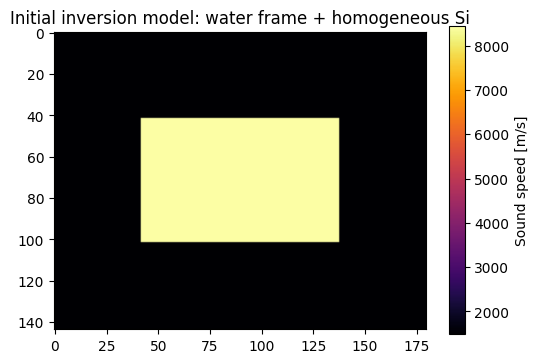

In [42]:
# ============================================================
# Verify the initial inversion model
# ============================================================

initial_sos = get_sound_speed(params).on_grid[..., 0]

print("Initial speed outside sample:")
print(float(initial_sos[0, 0]))

print("Initial speed inside sample:")
print(float(initial_sos[sample_top + 10, sample_left + 10]))

print("Expected water speed:", water_speed)
print("Expected silicon speed:", si_speed)

plt.figure(figsize=(6, 4))
plt.imshow(initial_sos, cmap="inferno")
plt.colorbar(label="Sound speed [m/s]")
plt.title("Initial inversion model: water frame + homogeneous Si")
plt.show()

In [43]:
# ============================================================
# Smoothness regularization
# Penalizes rough spatial variations in the inversion parameters
# ============================================================

regularization_weight = 1e-5
vertical_weight = 3.0
horizontal_weight = 1.0


def smoothness_regularization(params):
    p = params.on_grid[..., 0]

    vertical_diff = p[1:, :] - p[:-1, :]
    horizontal_diff = p[:, 1:] - p[:, :-1]

    reg = (
        vertical_weight * jnp.mean(vertical_diff ** 2)
        + horizontal_weight * jnp.mean(horizontal_diff ** 2)
    )

    return regularization_weight * reg


In [44]:
# ============================================================
# Optional: Penalize negative velocity updates
# Use only when you know the target anomaly should be faster
# than the background.
#
# WARNING:
# If the sample may contain voids, cracks, pores, or slow defects,
# this can hide the real defect. For void detection, set:
#     use_negative_update_penalty = False
# ============================================================

use_negative_update_penalty = True

negative_update_weight = 5e-7


def negative_update_regularization(params):
    velocity_update = (
        max_velocity_update
        * compose(params)(jnp.tanh)
        * mask
    )

    update_grid = velocity_update.on_grid[..., 0]

    # Keep only negative updates.
    # Positive updates become 0.
    negative_part = jnp.minimum(update_grid, 0.0)

    return negative_update_weight * jnp.mean(negative_part ** 2)

In [45]:
# ============================================================
# LOSS FUNCTION SELECTION
# Change only loss_name to test different losses
# ============================================================

from jwave.signal_processing import analytic_signal
from jaxdf.operators import gradient, functional


# Choose one:
# "mse"
# "envelope_mse"
# "normalized_l2"
# "global_normalized_mse"
# "trace_normalized_mse"
# "cross_correlation"
# "tracewise_cross_correlation"
# "log_envelope"
# "phase"
# "time_derivative_mse"
# "wasserstein_1d"
# "amplitude_envelope"
# "hybrid"

loss_name = "amplitude_envelope"


# ============================================================
# Helper functions
# ============================================================

def hilbert_transf(signal, noise=0.2):
    """
    Original envelope transform used in your code.
    """
    x = jnp.abs(analytic_signal(signal))
    return x


def safe_norm(x, eps=1e-8):
    return jnp.sqrt(jnp.sum(x ** 2) + eps)


def normalize_global(data, eps=1e-8):
    return data / (jnp.max(jnp.abs(data)) + eps)


def normalize_traces(data, eps=1e-8):
    """
    Normalize along time axis.

    In your code, p seems to have shape:
        time, sensors, maybe components

    So time is probably axis=0.
    """
    return data / (jnp.max(jnp.abs(data), axis=0, keepdims=True) + eps)


def time_derivative(data, dt):
    """
    Time derivative along time axis.
    """
    return (data[1:, ...] - data[:-1, ...]) / dt


# ============================================================
# Individual loss functions
# ============================================================

def mse_loss(predicted_data, observed_data, eps=1e-8):
    residual = predicted_data - observed_data
    return 0.5 * jnp.mean(residual ** 2)


def envelope_mse_loss(predicted_data, observed_data, eps=1e-8):
    """
    This is closest to your current loss.
    """
    predicted_env = hilbert_transf(predicted_data)
    observed_env = hilbert_transf(observed_data)

    residual = predicted_env - observed_env

    return 0.5 * jnp.mean(residual ** 2)


def normalized_l2_loss(predicted_data, observed_data, eps=1e-8):
    residual = predicted_data - observed_data

    numerator = jnp.sum(residual ** 2)
    denominator = jnp.sum(observed_data ** 2) + eps

    return 0.5 * numerator / denominator


def global_normalized_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_n = normalize_global(predicted_data, eps)
    observed_n = normalize_global(observed_data, eps)

    residual = predicted_n - observed_n

    return 0.5 * jnp.mean(residual ** 2)


def trace_normalized_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_n = normalize_traces(predicted_data, eps)
    observed_n = normalize_traces(observed_data, eps)

    residual = predicted_n - observed_n

    return 0.5 * jnp.mean(residual ** 2)


def cross_correlation_loss(predicted_data, observed_data, eps=1e-8):
    predicted_flat = predicted_data.reshape(-1)
    observed_flat = observed_data.reshape(-1)

    predicted_flat = predicted_flat - jnp.mean(predicted_flat)
    observed_flat = observed_flat - jnp.mean(observed_flat)

    numerator = jnp.sum(predicted_flat * observed_flat)

    denominator = (
        safe_norm(predicted_flat, eps)
        * safe_norm(observed_flat, eps)
    )

    corr = numerator / denominator

    return 1.0 - corr


def tracewise_cross_correlation_loss(predicted_data, observed_data, eps=1e-8):
    """
    Trace-wise correlation.

    Assumes time axis is axis=0.
    """
    predicted_zm = predicted_data - jnp.mean(
        predicted_data,
        axis=0,
        keepdims=True
    )

    observed_zm = observed_data - jnp.mean(
        observed_data,
        axis=0,
        keepdims=True
    )

    numerator = jnp.sum(predicted_zm * observed_zm, axis=0)

    denominator = (
        jnp.sqrt(jnp.sum(predicted_zm ** 2, axis=0) + eps)
        * jnp.sqrt(jnp.sum(observed_zm ** 2, axis=0) + eps)
    )

    corr_per_trace = numerator / denominator

    return 1.0 - jnp.mean(corr_per_trace)


def log_envelope_loss(predicted_data, observed_data, eps=1e-8):
    predicted_env = hilbert_transf(predicted_data)
    observed_env = hilbert_transf(observed_data)

    predicted_log = jnp.log(predicted_env + eps)
    observed_log = jnp.log(observed_env + eps)

    residual = predicted_log - observed_log

    return 0.5 * jnp.mean(residual ** 2)


def phase_loss(predicted_data, observed_data, eps=1e-8):
    predicted_analytic = analytic_signal(predicted_data)
    observed_analytic = analytic_signal(observed_data)

    predicted_phase = jnp.angle(predicted_analytic)
    observed_phase = jnp.angle(observed_analytic)

    phase_difference = predicted_phase - observed_phase

    phase_residual = jnp.angle(jnp.exp(1j * phase_difference))

    return 0.5 * jnp.mean(phase_residual ** 2)


def time_derivative_mse_loss(predicted_data, observed_data, eps=1e-8):
    predicted_dt = time_derivative(predicted_data, time_axis.dt)
    observed_dt = time_derivative(observed_data, time_axis.dt)

    residual = predicted_dt - observed_dt

    return 0.5 * jnp.mean(residual ** 2)


def positive_normalized_density(data, eps=1e-8):
    density = data ** 2
    density = density + eps

    density = density / jnp.sum(
        density,
        axis=0,
        keepdims=True
    )

    return density


def wasserstein_1d_loss(predicted_data, observed_data, eps=1e-8):
    predicted_density = positive_normalized_density(predicted_data, eps)
    observed_density = positive_normalized_density(observed_data, eps)

    predicted_cdf = jnp.cumsum(predicted_density, axis=0)
    observed_cdf = jnp.cumsum(observed_density, axis=0)

    residual = predicted_cdf - observed_cdf

    return jnp.mean(jnp.abs(residual))


def amplitude_envelope_loss(predicted_data, observed_data, eps=1e-8):
    alpha = 0.7

    waveform_part = trace_normalized_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    envelope_part = envelope_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    return alpha * waveform_part + (1.0 - alpha) * envelope_part


def hybrid_fwi_loss(predicted_data, observed_data, eps=1e-8):
    w_mse = 0.4
    w_corr = 0.3
    w_env = 0.2
    w_deriv = 0.1

    loss_mse = trace_normalized_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_corr = tracewise_cross_correlation_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_env = envelope_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    loss_deriv = time_derivative_mse_loss(
        predicted_data,
        observed_data,
        eps
    )

    return (
        w_mse * loss_mse
        + w_corr * loss_corr
        + w_env * loss_env
        + w_deriv * loss_deriv
    )


# ============================================================
# Loss selector
# ============================================================

def selected_loss(predicted_data, observed_data):
    if loss_name == "mse":
        return mse_loss(predicted_data, observed_data)

    elif loss_name == "envelope_mse":
        return envelope_mse_loss(predicted_data, observed_data)

    elif loss_name == "normalized_l2":
        return normalized_l2_loss(predicted_data, observed_data)

    elif loss_name == "global_normalized_mse":
        return global_normalized_mse_loss(predicted_data, observed_data)

    elif loss_name == "trace_normalized_mse":
        return trace_normalized_mse_loss(predicted_data, observed_data)

    elif loss_name == "cross_correlation":
        return cross_correlation_loss(predicted_data, observed_data)

    elif loss_name == "tracewise_cross_correlation":
        return tracewise_cross_correlation_loss(predicted_data, observed_data)

    elif loss_name == "log_envelope":
        return log_envelope_loss(predicted_data, observed_data)

    elif loss_name == "phase":
        return phase_loss(predicted_data, observed_data)

    elif loss_name == "time_derivative_mse":
        return time_derivative_mse_loss(predicted_data, observed_data)

    elif loss_name == "wasserstein_1d":
        return wasserstein_1d_loss(predicted_data, observed_data)

    elif loss_name == "amplitude_envelope":
        return amplitude_envelope_loss(predicted_data, observed_data)

    elif loss_name == "hybrid":
        return hybrid_fwi_loss(predicted_data, observed_data)

    else:
        raise ValueError(f"Unknown loss_name: {loss_name}")


# ============================================================
# Main loss function used by value_and_grad
# ============================================================

def loss_func(params, source_num):
    c0 = get_sound_speed(params)

    predicted_data = single_source_simulation(c0, source_num)

    observed_data = p_data[source_num]

    loss = selected_loss(
        predicted_data,
        observed_data
    )
    reg_loss = smoothness_regularization(params)
    loss = loss + reg_loss
    # Optional prior: discourage negative velocity updates
    if use_negative_update_penalty:
        loss = loss + negative_update_regularization(params)
    return loss


loss_with_grad = value_and_grad(loss_func, argnums=0)

print("Using loss function:", loss_name)
print("Regularization weight:", regularization_weight)

Using loss function: amplitude_envelope
Regularization weight: 1e-05


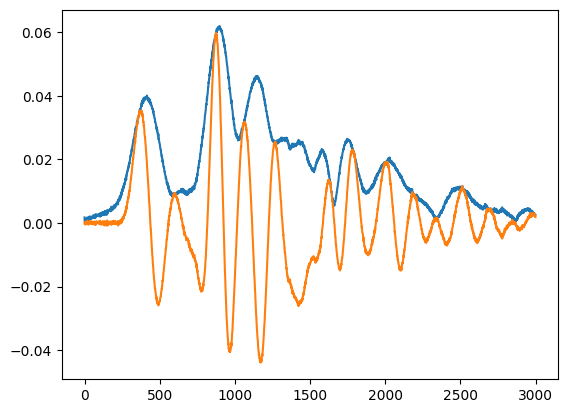

In [46]:
plt.plot(hilbert_transf(p_data[20, :, 0]))
plt.plot(p_data[20, :, 0])
plt.show()

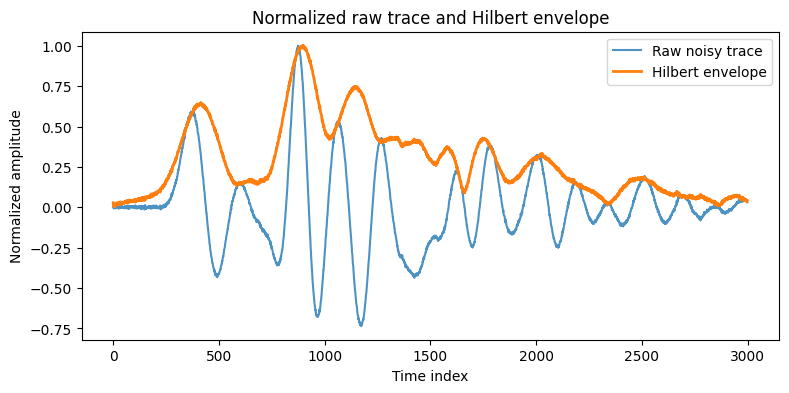

In [47]:
# ============================================================
# CHECK RAW TRACE + HILBERT ENVELOPE AFTER NOISE
# ============================================================

sensor_id = 20
source_id = 0

raw_trace = np.array(p_data[sensor_id, :, source_id])
env_trace = np.abs(np.array(analytic_signal(jnp.array(raw_trace))))

# Normalize only for visualization
raw_trace_norm = raw_trace / np.max(np.abs(raw_trace))
env_trace_norm = env_trace / np.max(env_trace)

plt.figure(figsize=(9, 4))
plt.plot(raw_trace_norm, label="Raw noisy trace", alpha=0.8)
plt.plot(env_trace_norm, label="Hilbert envelope", linewidth=2)
plt.title("Normalized raw trace and Hilbert envelope")
plt.xlabel("Time index")
plt.ylabel("Normalized amplitude")
plt.legend()
plt.show()

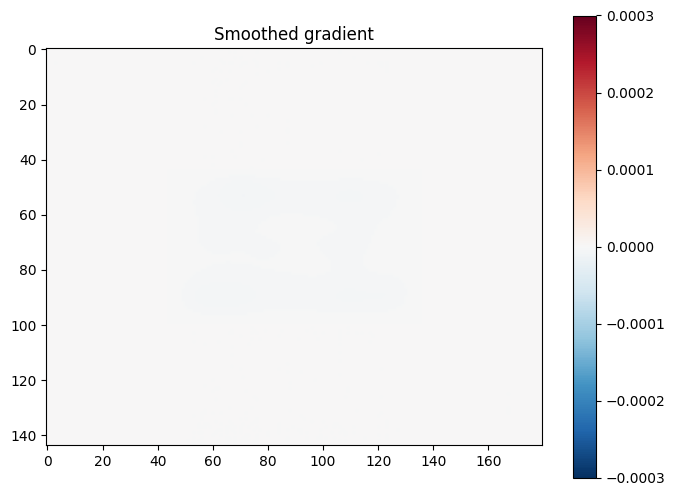

In [48]:
def smooth_fun(gradient):
    x = gradient.on_grid[..., 0]
    x = smooth(x)
    return gradient.replace_params(jnp.expand_dims(x, -1))

loss, gradient = loss_with_grad(params, source_num=10)
gradient = smooth_fun(gradient)

# Viualize
plt.figure(figsize=(8, 6))
plt.imshow(gradient.on_grid, cmap="RdBu_r", vmin=-0.0003, vmax=0.0003)
plt.title("Smoothed gradient")
plt.colorbar()
plt.show()

In [49]:
# ============================================================
# Validation loss over fixed sources
# ============================================================

validation_sources = jnp.array([0, 5, 10, 15, 20, 25, 30, 35])


def validation_loss(params):
    losses = []

    for src in validation_sources:
        loss_src = loss_func(params, int(src))
        losses.append(loss_src)

    return jnp.mean(jnp.array(losses))

In [50]:
losshistory = []
validation_losshistory = []
reconstructions = []
grad_mean_history = []
grad_min_history = []
grad_max_history = []
num_steps = 50
learning_rate = 0.03
sources_per_update = 4

# Define optimizer
init_fun, update_fun, get_params = optimizers.adam(learning_rate, 0.9, 0.9)
opt_state = init_fun(params)

# Define and compile the update function
# @jit
# def update(opt_state, key, k):
#     v = get_params(opt_state)
#     src_num = random.choice(key, num_sources)
#     lossval, gradient = loss_with_grad(v, src_num)
#     gradient_grid = gradient.on_grid
#     grad_min = jnp.min(gradient_grid)
#     grad_max = jnp.max(gradient_grid)
#     grad_mean = jnp.mean(jnp.abs(gradient_grid))
#     # IMPORTANT:
#     # mild smooothing
#     #gradient = smooth_fun(gradient)
#     return lossval, update_fun(k, gradient, opt_state), grad_min, grad_max, grad_mean

# ============================================================
# Multi-source mini-batch update
# Average gradients from several random laser-shot positions
# ============================================================

@jit
def update(opt_state, key, k):
    v = get_params(opt_state)
    # Choose several source positions for this update
    src_nums = random.choice(
        key,
        num_sources,
        shape=(sources_per_update,),
        replace=False
    )
    # Initial accumulators
    loss_sum = 0.0
    grad_grid_sum = jnp.zeros_like(v.on_grid)
    # Loop over selected sources
    for i in range(sources_per_update):
        src_num = src_nums[i]
        loss_i, grad_i = loss_with_grad(v, src_num)
        loss_sum = loss_sum + loss_i
        grad_grid_sum = grad_grid_sum + grad_i.on_grid
    # Average loss and gradient
    lossval = loss_sum / sources_per_update
    gradient_grid = grad_grid_sum / sources_per_update
    # Convert averaged gradient grid back to FourierSeries
    gradient = FourierSeries(
        gradient_grid,
        domain
    )
    # Diagnostics
    grad_min = jnp.min(gradient_grid)
    grad_max = jnp.max(gradient_grid)
    grad_mean = jnp.mean(jnp.abs(gradient_grid))
    # Keep smoothing OFF for this test
    # gradient = smooth_fun(gradient)
    return lossval, update_fun(k, gradient, opt_state), grad_min, grad_max, grad_mean


# Main loop
pbar = tqdm(range(num_steps))
_, key = random.split(random_seed)
for k in pbar:
    _, key = random.split(key)
    #lossval, opt_state = update(opt_state, key, k)
    lossval, opt_state, grad_min, grad_max, grad_mean = update(
        opt_state,
        key,
        k
    )

    ## For logging
    new_params = get_params(opt_state)
    reconstructions.append(get_sound_speed(new_params).on_grid)
    losshistory.append(float(lossval))
    grad_min_history.append(float(grad_min))
    grad_max_history.append(float(grad_max))
    grad_mean_history.append(float(grad_mean))
    
    # Validation loss every 5 steps

    if k % 5 == 0:

        val_loss = validation_loss(new_params)

        validation_losshistory.append(float(val_loss))

    else:

        validation_losshistory.append(validation_losshistory[-1])
    

    pbar.set_description(
        "Train loss: {:.6f}, Val loss: {:.6f}, Grad mean: {:.3e}".format(
            float(lossval),
            validation_losshistory[-1],
            float(grad_mean)
        )
    )

Train loss: 0.000048, Val loss: 0.000045, Grad mean: 3.316e-08: 100%|█████| 50/50 [29:38<00:00, 35.56s/it]


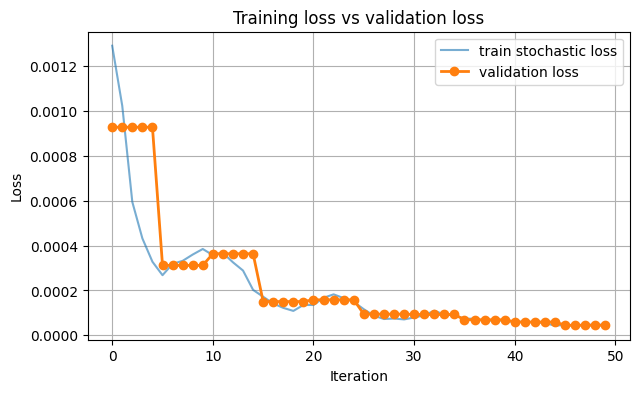

In [51]:
# ============================================================
# Plot training loss and validation loss
# Run this AFTER the FWI loop finishes
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory,
    label="train stochastic loss",
    alpha=0.6
)

plt.plot(
    validation_losshistory,
    label="validation loss",
    marker="o",
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

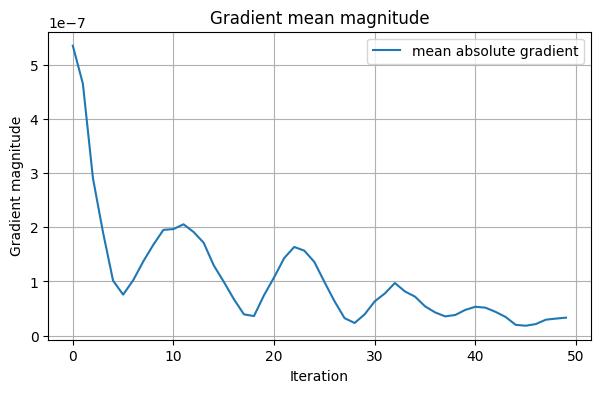

In [52]:
# ============================================================
# Plot gradient diagnostics
# Run this AFTER the FWI loop finishes
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    grad_mean_history,
    label="mean absolute gradient"
)

plt.xlabel("Iteration")
plt.ylabel("Gradient magnitude")
plt.title("Gradient mean magnitude")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

/var/folders/s7/3v2vl8f51x7b9mhx69n0gt480000gn/T/ipykernel_70177/2826385703.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


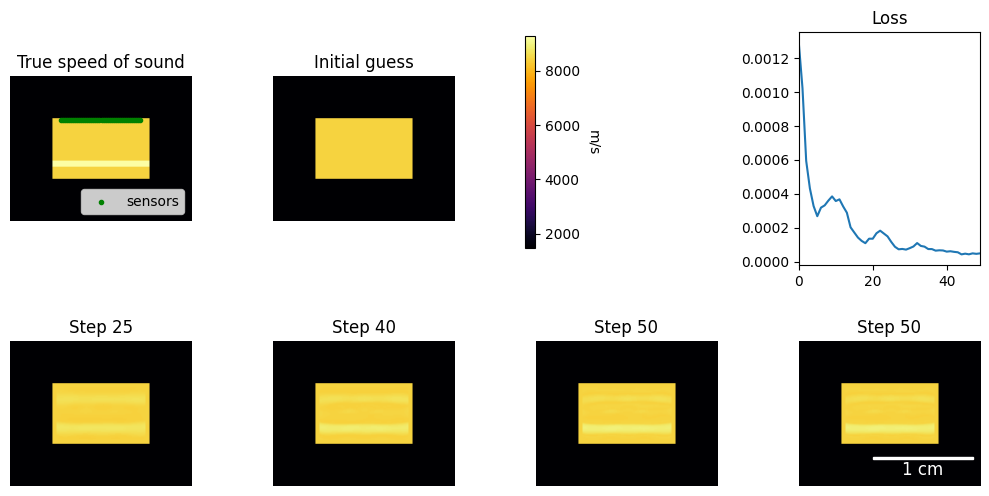

In [54]:
sos_original = get_sound_speed(params).on_grid
true_sos = sound_speed.on_grid
vmin = np.amin(true_sos)
vmax = np.amax(true_sos)

fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))

k = 0
#recs = [24, 39, 69, 99]
recs = [24, 39, 49, 49]
for row in range(2):
    for col in range(4):
        if k == 0:
            axes[row, col].imshow(true_sos, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].scatter(
                sensors_positions[1],
                sensors_positions[0],
                c="g",
                marker=".",
                label="sensors",
            )
            axes[row, col].legend(loc="lower right")
            axes[row, col].set_title("True speed of sound")
            axes[row, col].set_axis_off()
        elif k == 1:
            im_original = axes[row, col].imshow(sos_original, cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Initial guess")
            
            cbar_ax = fig.add_axes([0.53, 0.54, 0.01, 0.385])
            cbar = plt.colorbar(im_original, cax=cbar_ax)
            cbar.ax.get_yaxis().labelpad = 15
            cbar.ax.set_ylabel('m/s', rotation=270)
        elif k == 2:
            axes[row, col].set_axis_off()
        elif k == 3:
            axes[row, col].plot(losshistory)
            axes[row, col].set_title("Loss")
            #axes[row, col].set_xticks([], [])
            axes[row, col].margins(x=0)
        else:
            axes[row, col].imshow(reconstructions[recs[k - 4]], cmap="inferno", vmin=vmin, vmax=vmax)
            axes[row, col].set_axis_off()
            axes[row, col].set_title("Step {}".format(recs[k - 4] + 1))
        k += 1

# Scale bar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(
    axes[-1, -1].transData,
    100, '1 cm', 'lower right', 
    pad=0.3,
    color='white',
    frameon=False,
    size_vertical=2,
    fontproperties=fontprops)
axes[-1, -1].add_artist(scalebar)
        
fig.tight_layout()

plt.savefig('fwi.pdf')

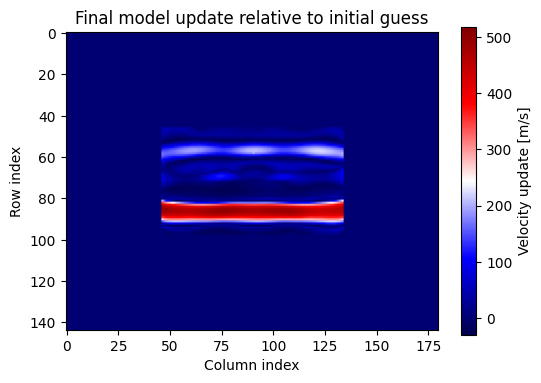

In [55]:
# ============================================================
# Plot model update relative to initial guess
# ============================================================

initial_sos = get_sound_speed(params).on_grid
final_sos = get_sound_speed(get_params(opt_state)).on_grid

model_update = final_sos - initial_sos

plt.figure(figsize=(6, 4))
plt.imshow(model_update, cmap="seismic")
plt.colorbar(label="Velocity update [m/s]")
plt.title("Final model update relative to initial guess")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

In [56]:
initial_sos = get_sound_speed(params).on_grid
final_sos = get_sound_speed(get_params(opt_state)).on_grid

print("Min update:", float(jnp.min(final_sos - initial_sos)))
print("Max update:", float(jnp.max(final_sos - initial_sos)))
print("Mean abs update:", float(jnp.mean(jnp.abs(final_sos - initial_sos))))

Min update: -30.091796875
Max update: 518.015625
Mean abs update: 18.170833587646484


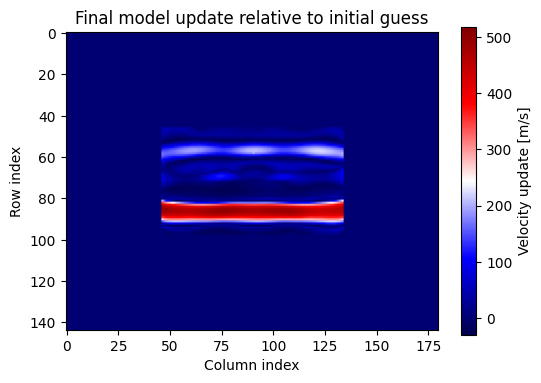

In [57]:
# ============================================================
# Plot final model update relative to initial guess
# ============================================================

plt.figure(figsize=(6, 4))

plt.imshow(
    model_update,
    cmap="seismic"
)

plt.colorbar(label="Velocity update [m/s]")
plt.title("Final model update relative to initial guess")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()

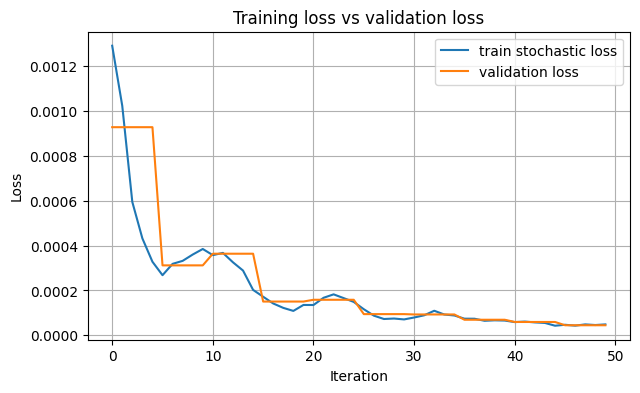

In [58]:

# ============================================================
# Plot training loss and validation loss separately
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    losshistory,
    label="train stochastic loss"
)

plt.plot(
    validation_losshistory,
    label="validation loss"
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss vs validation loss")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
initial_sos = get_sound_speed(params).on_grid[..., 0]
final_sos = get_sound_speed(get_params(opt_state)).on_grid[..., 0]

model_update = final_sos - initial_sos

print("Sources per update:", sources_per_update)
print("Learning rate:", learning_rate)
print("Num steps:", num_steps)
print("Initial validation loss:", validation_losshistory[0])
print("Final validation loss:", validation_losshistory[-1])
print("Min update:", float(jnp.min(model_update)))
print("Max update:", float(jnp.max(model_update)))
print("Mean abs update:", float(jnp.mean(jnp.abs(model_update))))

Sources per update: 4
Learning rate: 0.03
Num steps: 50
Initial validation loss: 0.0009272700408473611
Final validation loss: 4.463794903131202e-05
Min update: -30.091796875
Max update: 518.015625
Mean abs update: 18.170833587646484
